# Feature Descriptions

- **person_age:** The age of the individual applying for the loan.
- **person_income:** The applicant's annual income.
- **person_home_ownership:** Indicates the applicant's type of home ownership:
  - rent: The individual is currently renting.
  - mortgage: The home is being paid for through a mortgage.
  - own: The individual fully owns their home.
  - other: Any other form of ownership not categorized above.|
- **person_emp_length:** Number of years the person has been employed.
- **loan_intent:** The stated purpose or intent for the loan application.
- **loan_grade:** A rating that reflects the credit risk of the loan:
  - A: Very low risk, highly creditworthy.
  - B: Low risk, though slightly less creditworthy than A.
  - C: Moderate credit risk.
  - D: Noticeably higher risk.
  - E: Increased credit risk.
  - F: High risk borrower.
  - G: The highest level of credit risk.
- **loan_amnt:** The total amount of money requested in the loan.
- **loan_int_rate:** The interest rate assigned to the loan.
- **loan_status:** Indicates whether the loan was defaulted:
  - 0: Non-default – the borrower repaid the loan as agreed.
  - 1: Default – the borrower failed to meet the repayment terms.
- **loan_percent_income:** The loan amount as a percentage of the applicant's income.
- **cb_person_default_on_file:** Whether the credit bureau has a record of past defaults:
  - Y: The person has a history of default.
  - N: No default history found.
- **cb_preson_cred_hist_length:** The length of the person’s credit history in years.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier as DTC, DecisionTreeRegressor as DTR 
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Load and Preview Dataset  
This section reads a CSV file containing credit risk data into a pandas DataFrame and displays the first few rows. It helps in getting an initial look at the dataset's structure and contents.


In [2]:
my_data_set = pd.read_csv('C:/Users/User/Desktop/credit_risk_dataset.csv', encoding='utf-8')
print(my_data_set.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


### Explore Dataset Structure and Statistics  
This section gives an overview of the dataset, including its dimensions, data types, presence of missing values, and summary statistics of numerical features. It helps understand the data's overall structure and quality.


In [3]:
my_data_set.shape
my_data_set.info()
my_data_set.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Summarize Categorical Features  
This section provides descriptive statistics for categorical columns in the dataset, including the number of unique values, the most frequent category, and its frequency. It helps in understanding the distribution of non-numeric data.


In [4]:
my_data_set.describe(include='O')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


### Check for Missing Values  
This section identifies missing values in the dataset by counting the number of null entries in each column. It helps detect incomplete data that may need to be handled before analysis or modeling.


In [5]:
my_data_set.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### Visualize Feature Relationships  
This section uses a pair plot to explore relationships between numerical features in the dataset. The data points are color-coded based on loan status, which helps in identifying trends, patterns, and potential class separations.


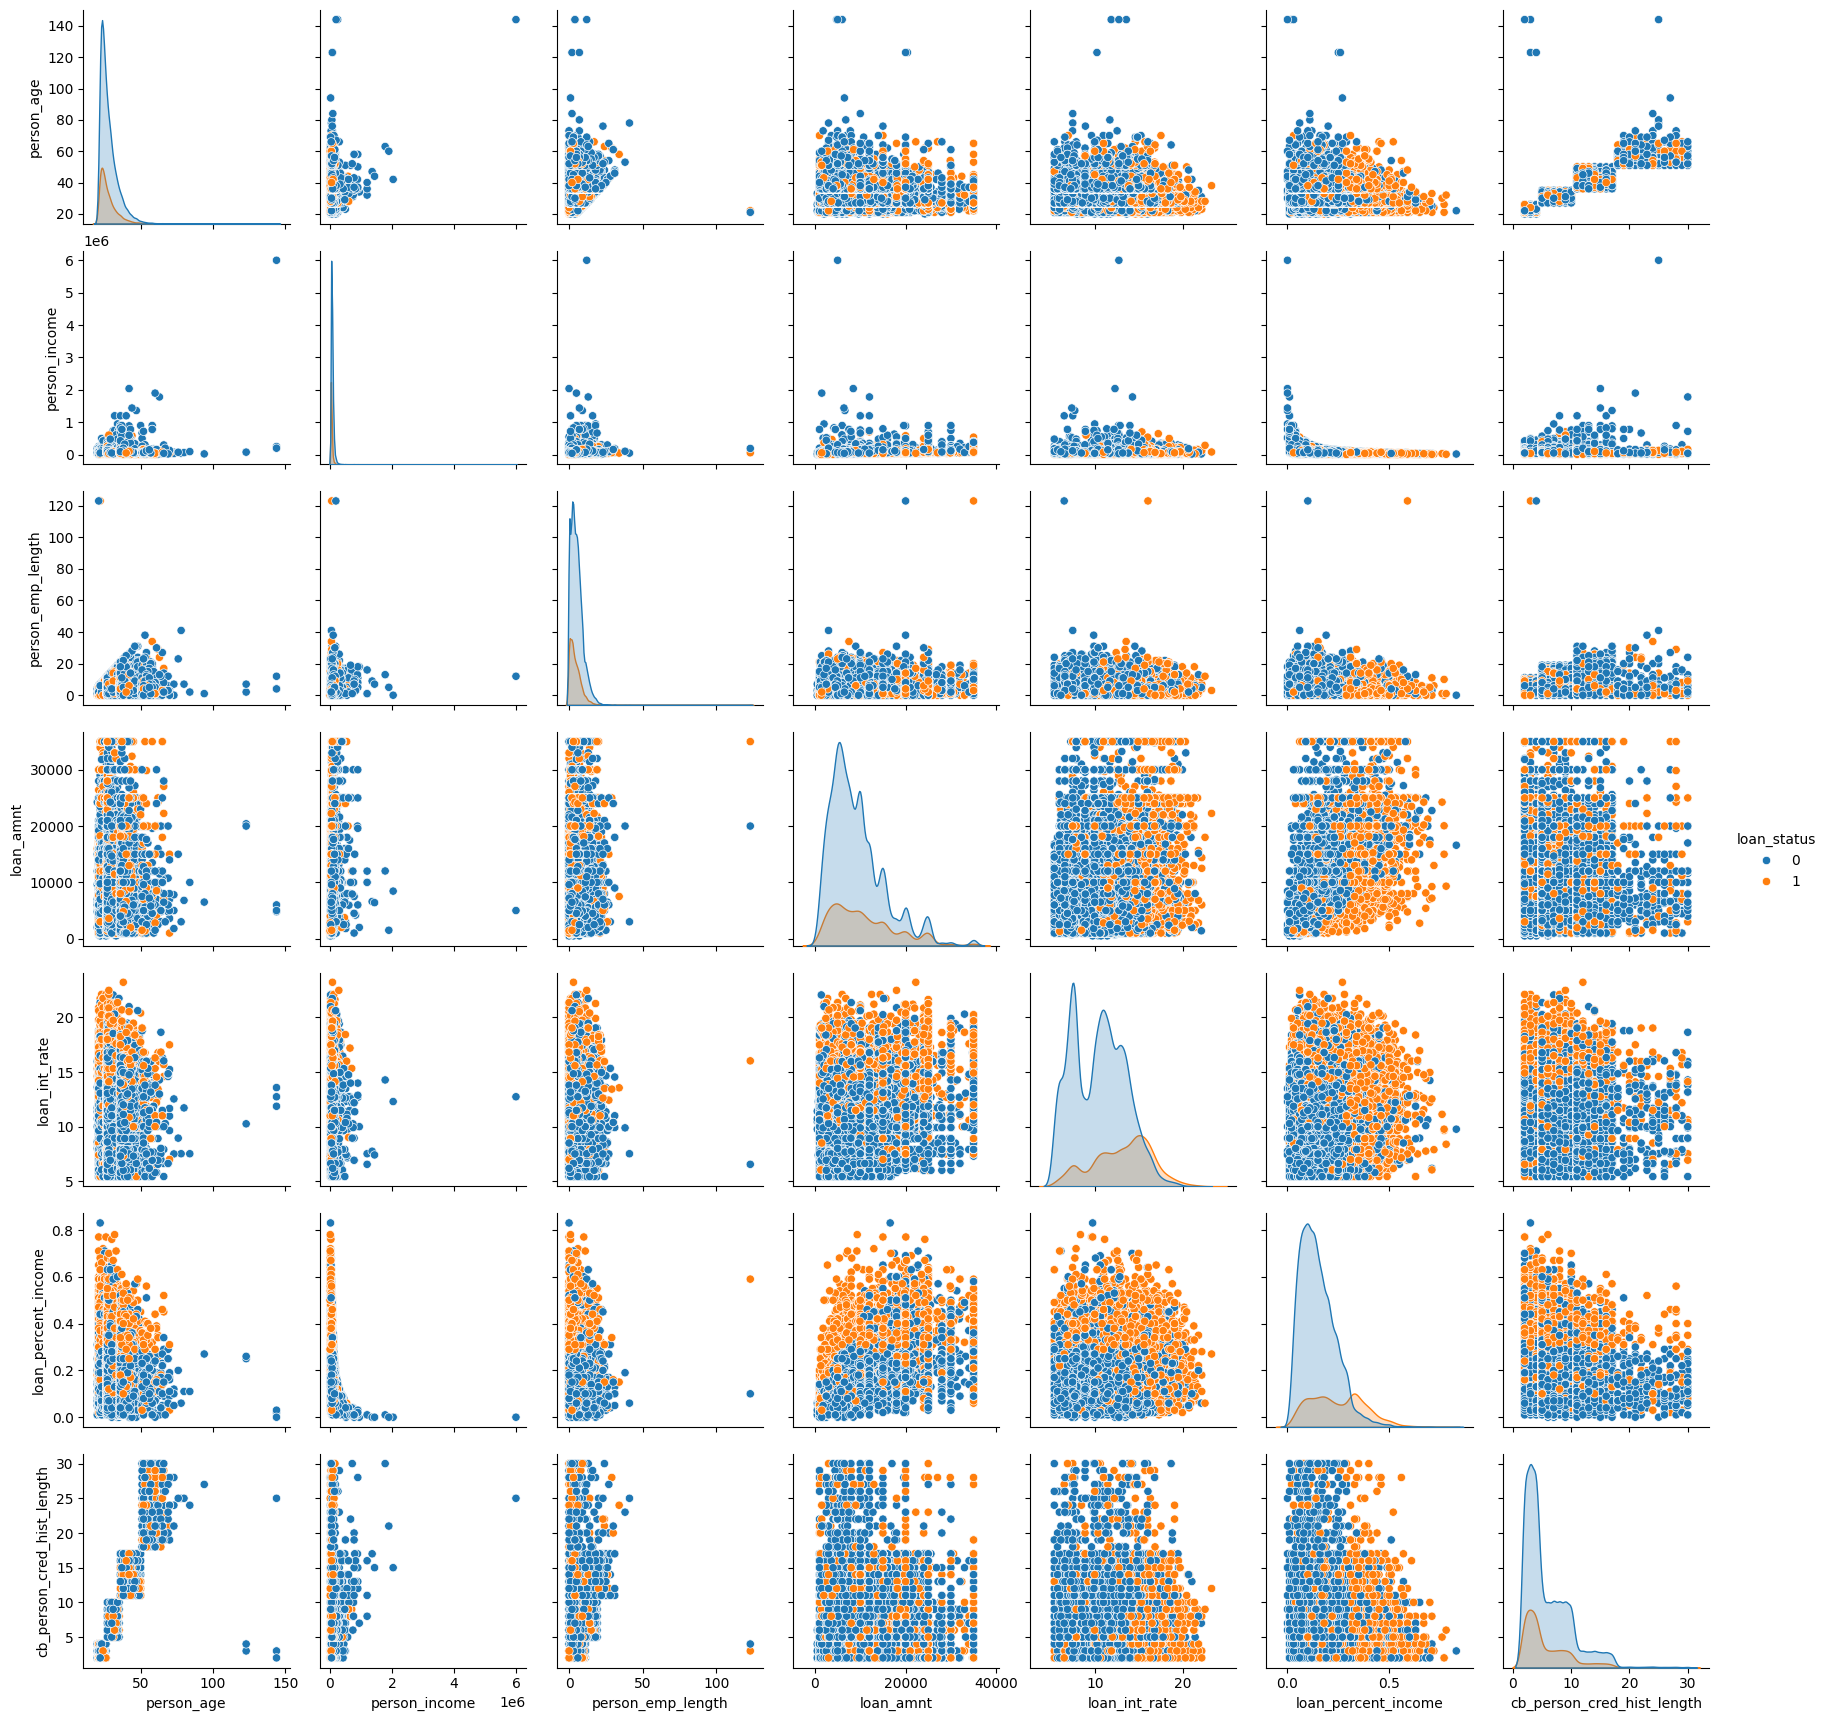

In [6]:
sns.pairplot(data = my_data_set, hue='loan_status')

### Analyze Employment Length Distribution  
This section visualizes the distribution of the `person_emp_length` feature to decide how to handle missing values. By comparing the mean and median on the histogram, it helps determine which statistic is more appropriate for filling in the null values.


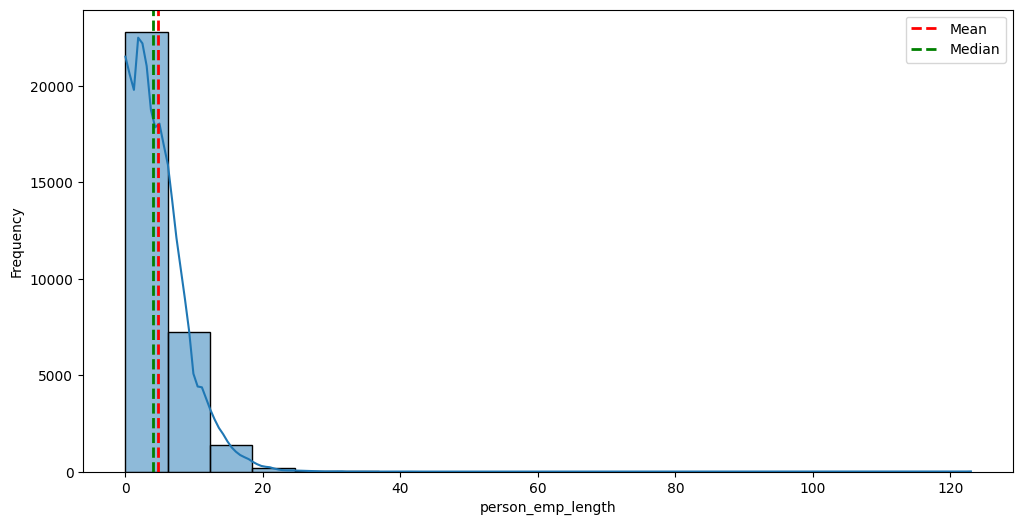

In [7]:
plt.figure(figsize=(12, 6))
sns.histplot(my_data_set['person_emp_length'].dropna(), bins=20, kde=True)
mean_value = my_data_set['person_emp_length'].mean()
median_value = my_data_set['person_emp_length'].median()
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(median_value, color='green', linestyle='dashed', linewidth=2, label='Median')
plt.xlabel('person_emp_length')
plt.ylabel('Frequency')
plt.legend()

### Fill Missing Employment Length Values  
Based on the distribution analysis, this step fills missing values in the `person_emp_length` column using the median. This approach is chosen to minimize the influence of outliers and better represent the typical value.


In [3]:
my_data_set['person_emp_length'].fillna(my_data_set['person_emp_length'].median(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_11940\2695155498.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  my_data_set['person_emp_length'].fillna(my_data_set['person_emp_length'].median(), inplace=True)


In [9]:
my_data_set.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### Analyze Loan Interest Rate Distribution  
This section visualizes the distribution of loan interest rates and compares the mean and median. It is used to assess the central tendency and decide whether to fill missing values with the mean or median.


11.011694892245036 10.99


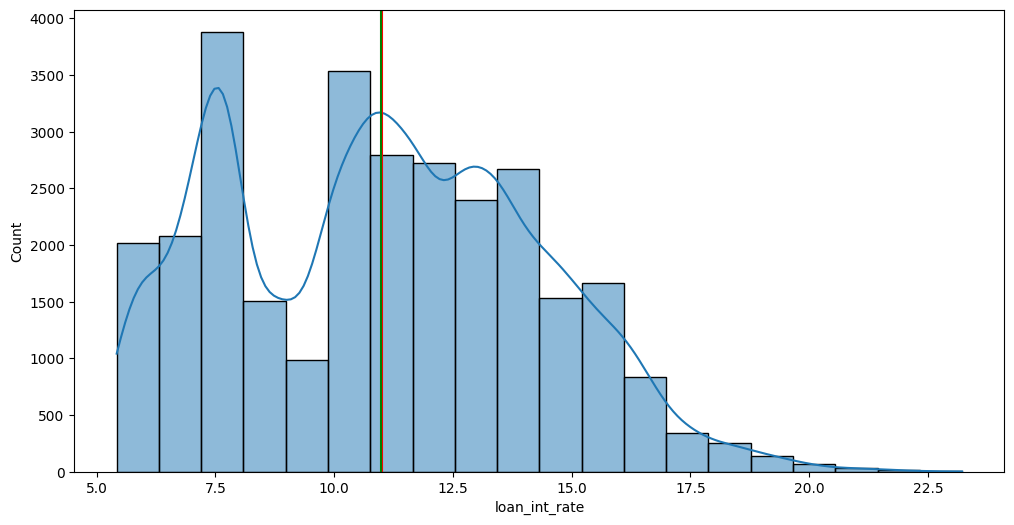

In [3]:
plt.figure(figsize=(12, 6))
sns.histplot(my_data_set['loan_int_rate'].dropna(), bins=20, kde=True)
mean, median = my_data_set['loan_int_rate'].mean(), my_data_set['loan_int_rate'].median()
plt.axvline(mean, color='red')
plt.axvline(median, color ='green')
print(mean, median)

In [4]:
# filling with the mean
my_data_set['loan_int_rate'].fillna(my_data_set['loan_int_rate'].mean(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_12856\1936466025.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  my_data_set['loan_int_rate'].fillna(my_data_set['loan_int_rate'].mean(), inplace=True)


In [5]:
my_data_set.isnull().sum()

person_age                      0
person_income                   0
person_home_ownership           0
person_emp_length             895
loan_intent                     0
loan_grade                      0
loan_amnt                       0
loan_int_rate                   0
loan_status                     0
loan_percent_income             0
cb_person_default_on_file       0
cb_person_cred_hist_length      0
dtype: int64

In [6]:
cols = my_data_set.select_dtypes(include='O').columns
cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

### Encode Categorical Variables  
This section converts categorical columns into numeric labels using Label Encoding. This transformation is essential for many machine learning models that can only process numerical data.


In [7]:
lenc = LabelEncoder()
for col in cols:
    my_data_set[col] = lenc.fit_transform(my_data_set[col])
my_data_set

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,3,123.0,4,3,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,0,1.0,4,2,5800,13.16,0,0.11,0,30
32577,54,120000,0,4.0,4,0,17625,7.49,0,0.15,0,19
32578,65,76000,3,3.0,2,1,35000,10.99,1,0.46,0,28
32579,56,150000,0,5.0,4,1,15000,11.48,0,0.10,0,26


In [15]:
my_data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  int64  
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  int64  
 5   loan_grade                  32581 non-null  int64  
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  int64  
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 3.0 MB


In [8]:
my_data_set.duplicated().sum()

np.int64(165)

In [9]:
my_data_set = my_data_set.drop_duplicates()
my_data_set.duplicated().sum()

np.int64(0)

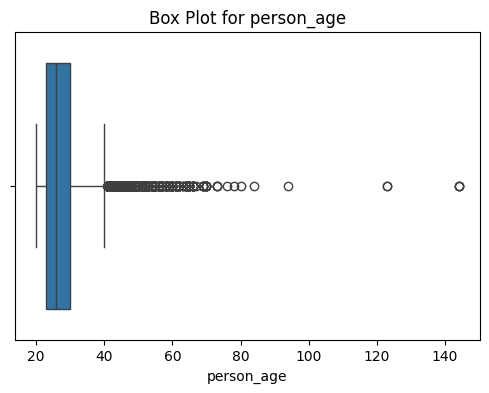

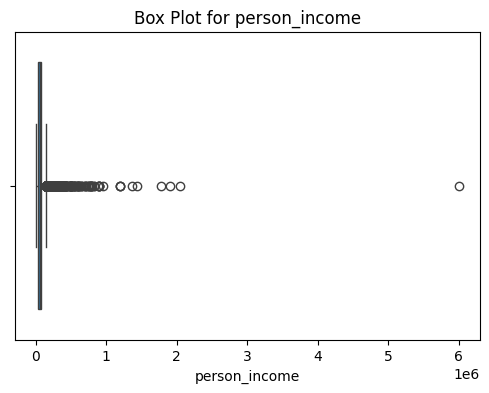

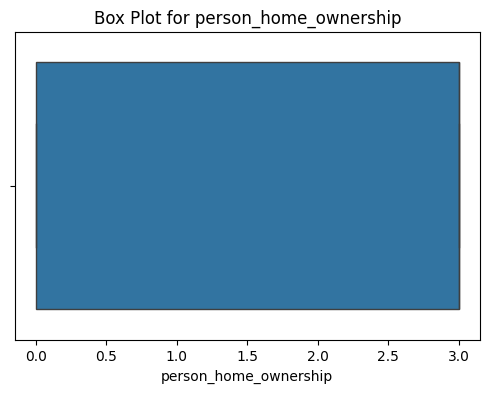

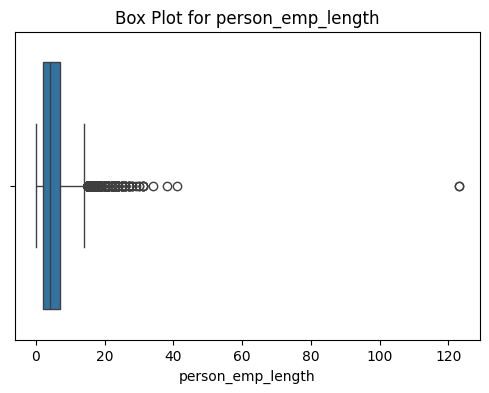

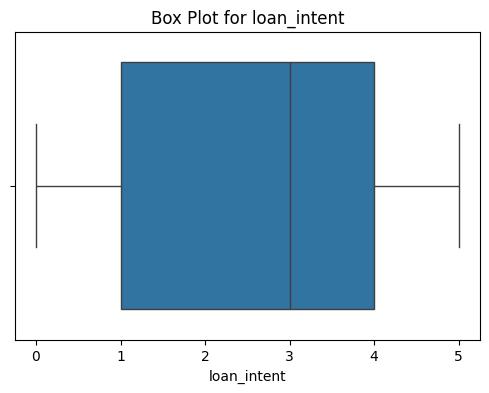

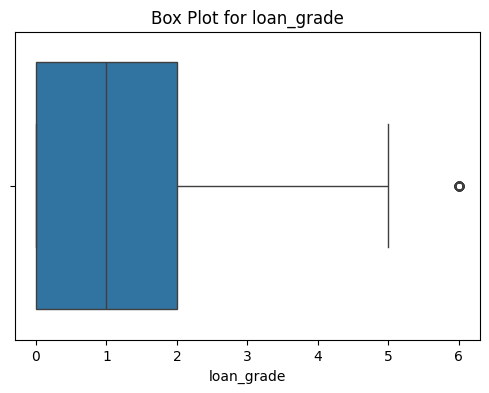

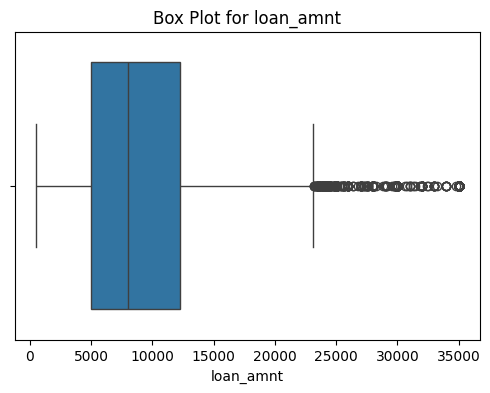

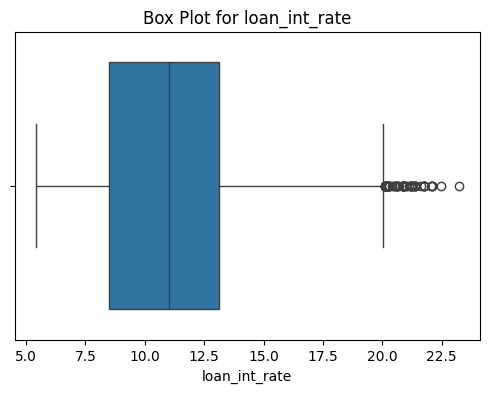

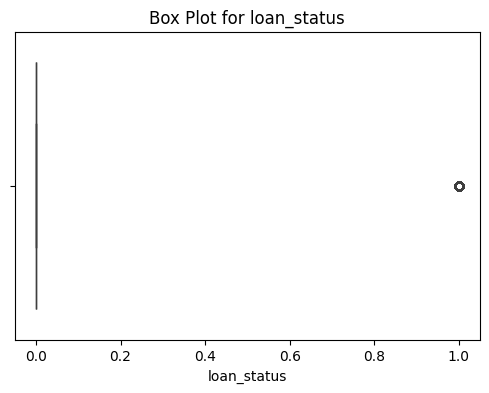

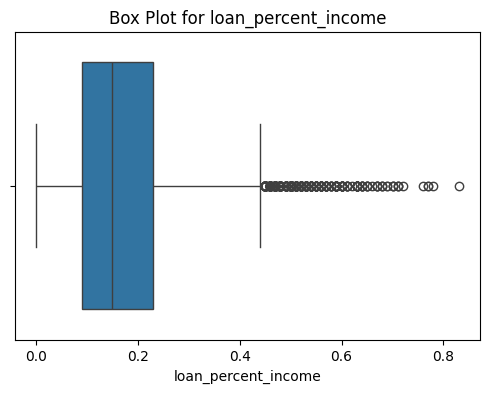

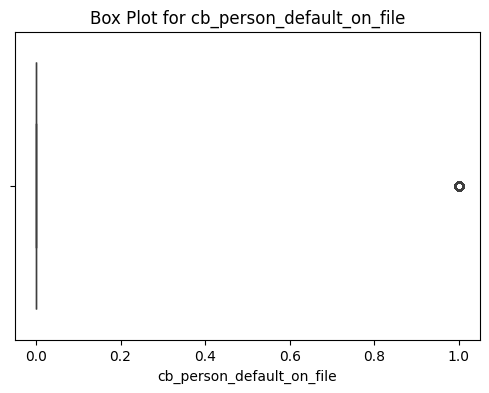

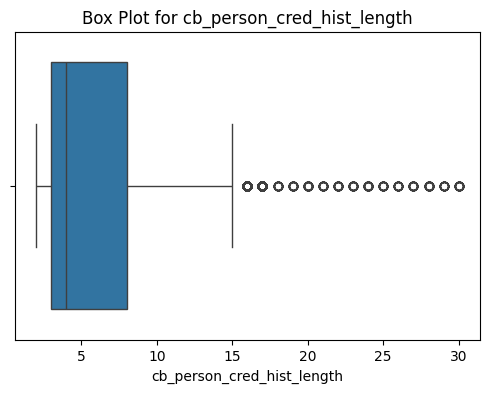

In [18]:
for col in my_data_set.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=my_data_set[col])
    plt.title(f'Box Plot for {col}')
    plt.show()

### Remove Age Outliers  
This section filters out data points with `person_age` greater than 80, identified as outliers through box plot analysis. Removing these extreme values helps improve data quality and model performance.


In [10]:
my_data_set = my_data_set.drop(my_data_set[my_data_set['person_age'] > 80].index, axis=0)

In [11]:
my_data_set['age_group'] = pd.cut(my_data_set['person_age'],
                           bins=[20, 26, 36, 46, 56, 66, 80],
                           labels=['20-25', '26-35', '36-45', '46-55', '56-65', '66-80'])

### Remove income Outliers  
This section filters out data points with `person_income` greater than 80, identified as outliers through box plot analysis. Removing these extreme values helps improve data quality and model performance.


In [12]:
my_data_set = my_data_set.drop(my_data_set[my_data_set['person_income'] > 1000000].index, axis=0)

In [13]:
my_data_set['income_group'] = pd.cut(my_data_set['person_income'],
                              bins=[0, 25000, 50000, 75000, 100000, float('inf')],
                              labels=['low', 'low-middle', 'middle', 'high-middle', 'high'])

### Remove emp_length Outliers  
This section filters out data points with `person_emp_length` greater than 80, identified as outliers through box plot analysis. Removing these extreme values helps improve data quality and model performance.


In [14]:
my_data_set = my_data_set.drop(my_data_set[my_data_set['person_emp_length'] > 60].index, axis=0)

In [15]:
cols = my_data_set.select_dtypes(include='category').columns
cols

Index(['age_group', 'income_group'], dtype='object')

In [16]:
lenc = LabelEncoder()
for col in cols:
    my_data_set[col] = lenc.fit_transform(my_data_set[col])
my_data_set

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group,income_group
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3,0,2
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2,0,4
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4,0,4
5,21,9900,2,2.0,5,0,2500,7.14,1,0.25,0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,0,1.0,4,2,5800,13.16,0,0.11,0,30,4,4
32577,54,120000,0,4.0,4,0,17625,7.49,0,0.15,0,19,3,0
32578,65,76000,3,3.0,2,1,35000,10.99,1,0.46,0,28,4,1
32579,56,150000,0,5.0,4,1,15000,11.48,0,0.10,0,26,3,0


### Feature Engineering with Ratios  
This section generates new features by calculating ratios between existing variables to capture relationships that may improve model predictions. However, only the loan-to-income ratio was found to be effective.


In [17]:
my_data_set['loan_to_income_ratio'] = my_data_set['loan_amnt'] / my_data_set['person_income']
my_data_set['loan_to_emp_length_ratio'] =  my_data_set['person_emp_length']/ my_data_set['loan_amnt'] 
my_data_set['int_rate_to_loan_amt_ratio'] = my_data_set['loan_int_rate'] / my_data_set['loan_amnt']

In [18]:
X = my_data_set.drop(columns=['loan_status', 'person_age', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'age_group', 'income_group', 'loan_to_emp_length_ratio', 'int_rate_to_loan_amt_ratio'])
y = my_data_set['loan_status']

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)


In [20]:
tree_clf1 = DTC()
tree_clf1.fit(X_train, y_train)

DecisionTreeClassifier()

In [21]:
tree_clf1.get_depth()

31

In [22]:
tree_clf1.get_n_leaves()

np.int64(2612)

In [23]:
features = tree_clf1.feature_names_in_
features

array(['person_income', 'person_home_ownership', 'loan_intent',
       'loan_grade', 'loan_percent_income', 'loan_to_income_ratio'],
      dtype=object)

### Extract Feature Importances  
This section obtains the importance values of each feature from the trained decision tree classifier. These scores help identify which features have the greatest impact on the model's decisions.


In [24]:
importance = tree_clf1.feature_importances_
importance

array([0.19219019, 0.14309205, 0.10262135, 0.17455291, 0.06538417,
       0.32215934])

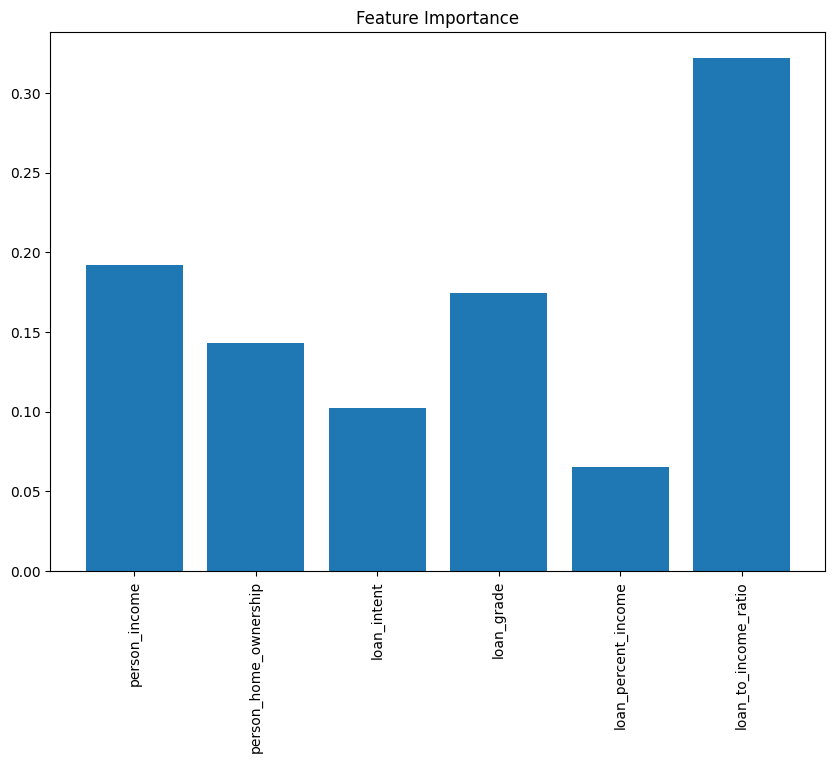

In [25]:
plt.figure(figsize=(10,7))
plt.bar(features, importance)
plt.title('Feature Importance')
plt.xticks(rotation=90);

In [26]:
print(f"Training accuracy : {tree_clf1.score(X_train, y_train)}")
print(f"Test accuracy {tree_clf1.score(X_test, y_test)}")

Training accuracy : 0.9963402266413863
Test accuracy 0.8841563786008231


## <span style="color: red">Post Pruning✂️🌳 </span>

- Post-pruning is a technique where the decision tree is allowed to grow to its maximum depth and then parts of the tree are removed to prevent overfitting.
- Subtrees of the full tree are evaluated using criteria such as mean squared error (MSE) for regression trees or classification error for classification trees.
- Post pruning involves converting leaves to nodes and removing subtrees based on the evaluation criteria.
The challenge with post pruning is that evaluating every branch of a large tree can be computationally expensive.

### Optimize Decision Tree with Cost Complexity Pruning  
This section performs cost complexity pruning on the decision tree classifier to prevent overfitting and improve generalization.  

- First, it computes a range of pruning parameters (`ccp_alpha`) using the training data.  
- Then, for each `ccp_alpha` value, it trains a new decision tree with that pruning level.  
- After training, it evaluates each model's accuracy on the test set to see how pruning affects performance.  
- It records the accuracy scores and selects the model with the highest accuracy as the best-pruned tree.  
- Finally, it prints details about the best model, including the pruning iteration, accuracy, and the optimal `ccp_alpha` value.  

This process helps find the right balance between model complexity and accuracy by removing unnecessary branches, thus reducing overfitting while maintaining good predictive power.


In [27]:
#ccp alpha = cost complexity parameter alpha
path = tree_clf1.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
models = []
accuracies = []


for i, ccp_alpha in enumerate(ccp_alphas):
    model = DTC(random_state=42, ccp_alpha=ccp_alpha)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"Accuracy with pruning #{i+1}: {accuracy:.4f}")
    models.append(model)
    accuracies.append(accuracy)


best_index = accuracies.index(max(accuracies))
best_model = models[best_index]
best_accuracy = accuracies[best_index]
best_ccp_alpha = ccp_alphas[best_index]

print(f"\nBest model found:")
print(f"Pruning #{best_index+1}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"ccp_alpha: {best_ccp_alpha:.6f}")

Accuracy with pruning #1: 0.8852
Accuracy with pruning #2: 0.8852
Accuracy with pruning #3: 0.8852
Accuracy with pruning #4: 0.8851
Accuracy with pruning #5: 0.8851
Accuracy with pruning #6: 0.8851
Accuracy with pruning #7: 0.8851
Accuracy with pruning #8: 0.8851
Accuracy with pruning #9: 0.8851
Accuracy with pruning #10: 0.8851
Accuracy with pruning #11: 0.8851
Accuracy with pruning #12: 0.8851
Accuracy with pruning #13: 0.8851
Accuracy with pruning #14: 0.8851
Accuracy with pruning #15: 0.8851
Accuracy with pruning #16: 0.8851
Accuracy with pruning #17: 0.8851
Accuracy with pruning #18: 0.8851
Accuracy with pruning #19: 0.8849
Accuracy with pruning #20: 0.8849
Accuracy with pruning #21: 0.8849
Accuracy with pruning #22: 0.8849
Accuracy with pruning #23: 0.8849
Accuracy with pruning #24: 0.8849
Accuracy with pruning #25: 0.8849
Accuracy with pruning #26: 0.8849
Accuracy with pruning #27: 0.8849
Accuracy with pruning #28: 0.8849
Accuracy with pruning #29: 0.8849
Accuracy with pruning #

### Visualize Accuracy vs. Pruning Parameter  
This section plots the relationship between the cost complexity pruning parameter (`ccp_alpha`) and the model's accuracy on the test set. The graph helps to visually analyze how pruning affects performance and to select the optimal pruning level.


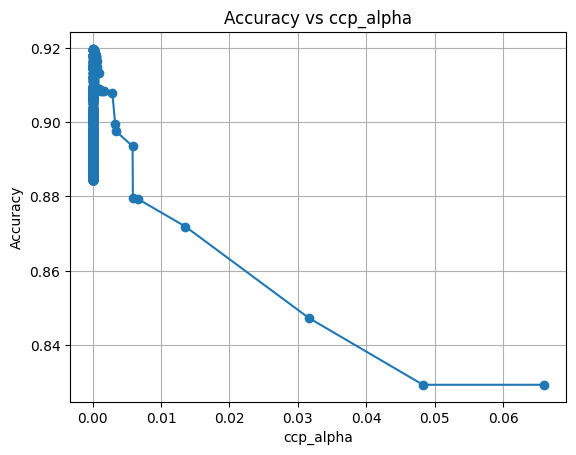

In [28]:
import matplotlib.pyplot as plt
plt.plot(ccp_alphas, accuracies, marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs ccp_alpha')
plt.grid(True)
plt.show()

In [29]:
tree_clf2 = DTC(ccp_alpha=best_ccp_alpha)
tree_clf2.fit(X_train, y_train)
predictions_tree = tree_clf2.predict(X_test)
tree_clf2.score(X_train, y_train), tree_clf2.score(X_test, y_test)


(0.9265399708981877, 0.9198559670781893)

### Evaluate Decision Tree Model Performance  
This section assesses the decision tree’s predictive performance by plotting the confusion matrix, which shows the counts of true vs. predicted labels. It also calculates and prints the overall accuracy score, providing a quantitative measure of how well the model performs on the test data.


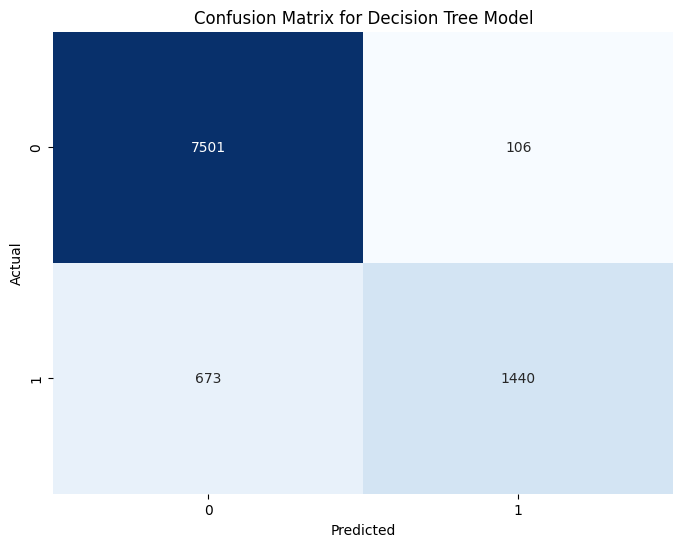

Accuracy of the Decision Tree Model: 0.9199


In [30]:
cm = confusion_matrix(y_test, predictions_tree)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix for Decision Tree Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


accuracy = accuracy_score(y_test, predictions_tree)
print(f"Accuracy of the Decision Tree Model: {accuracy:.4f}")

### Visualize Decision Tree Structure  
This section creates a detailed plot of the decision tree, illustrating how the model splits on different features to classify data. The colored nodes represent different predicted classes, helping to understand the decision-making process of the tree.


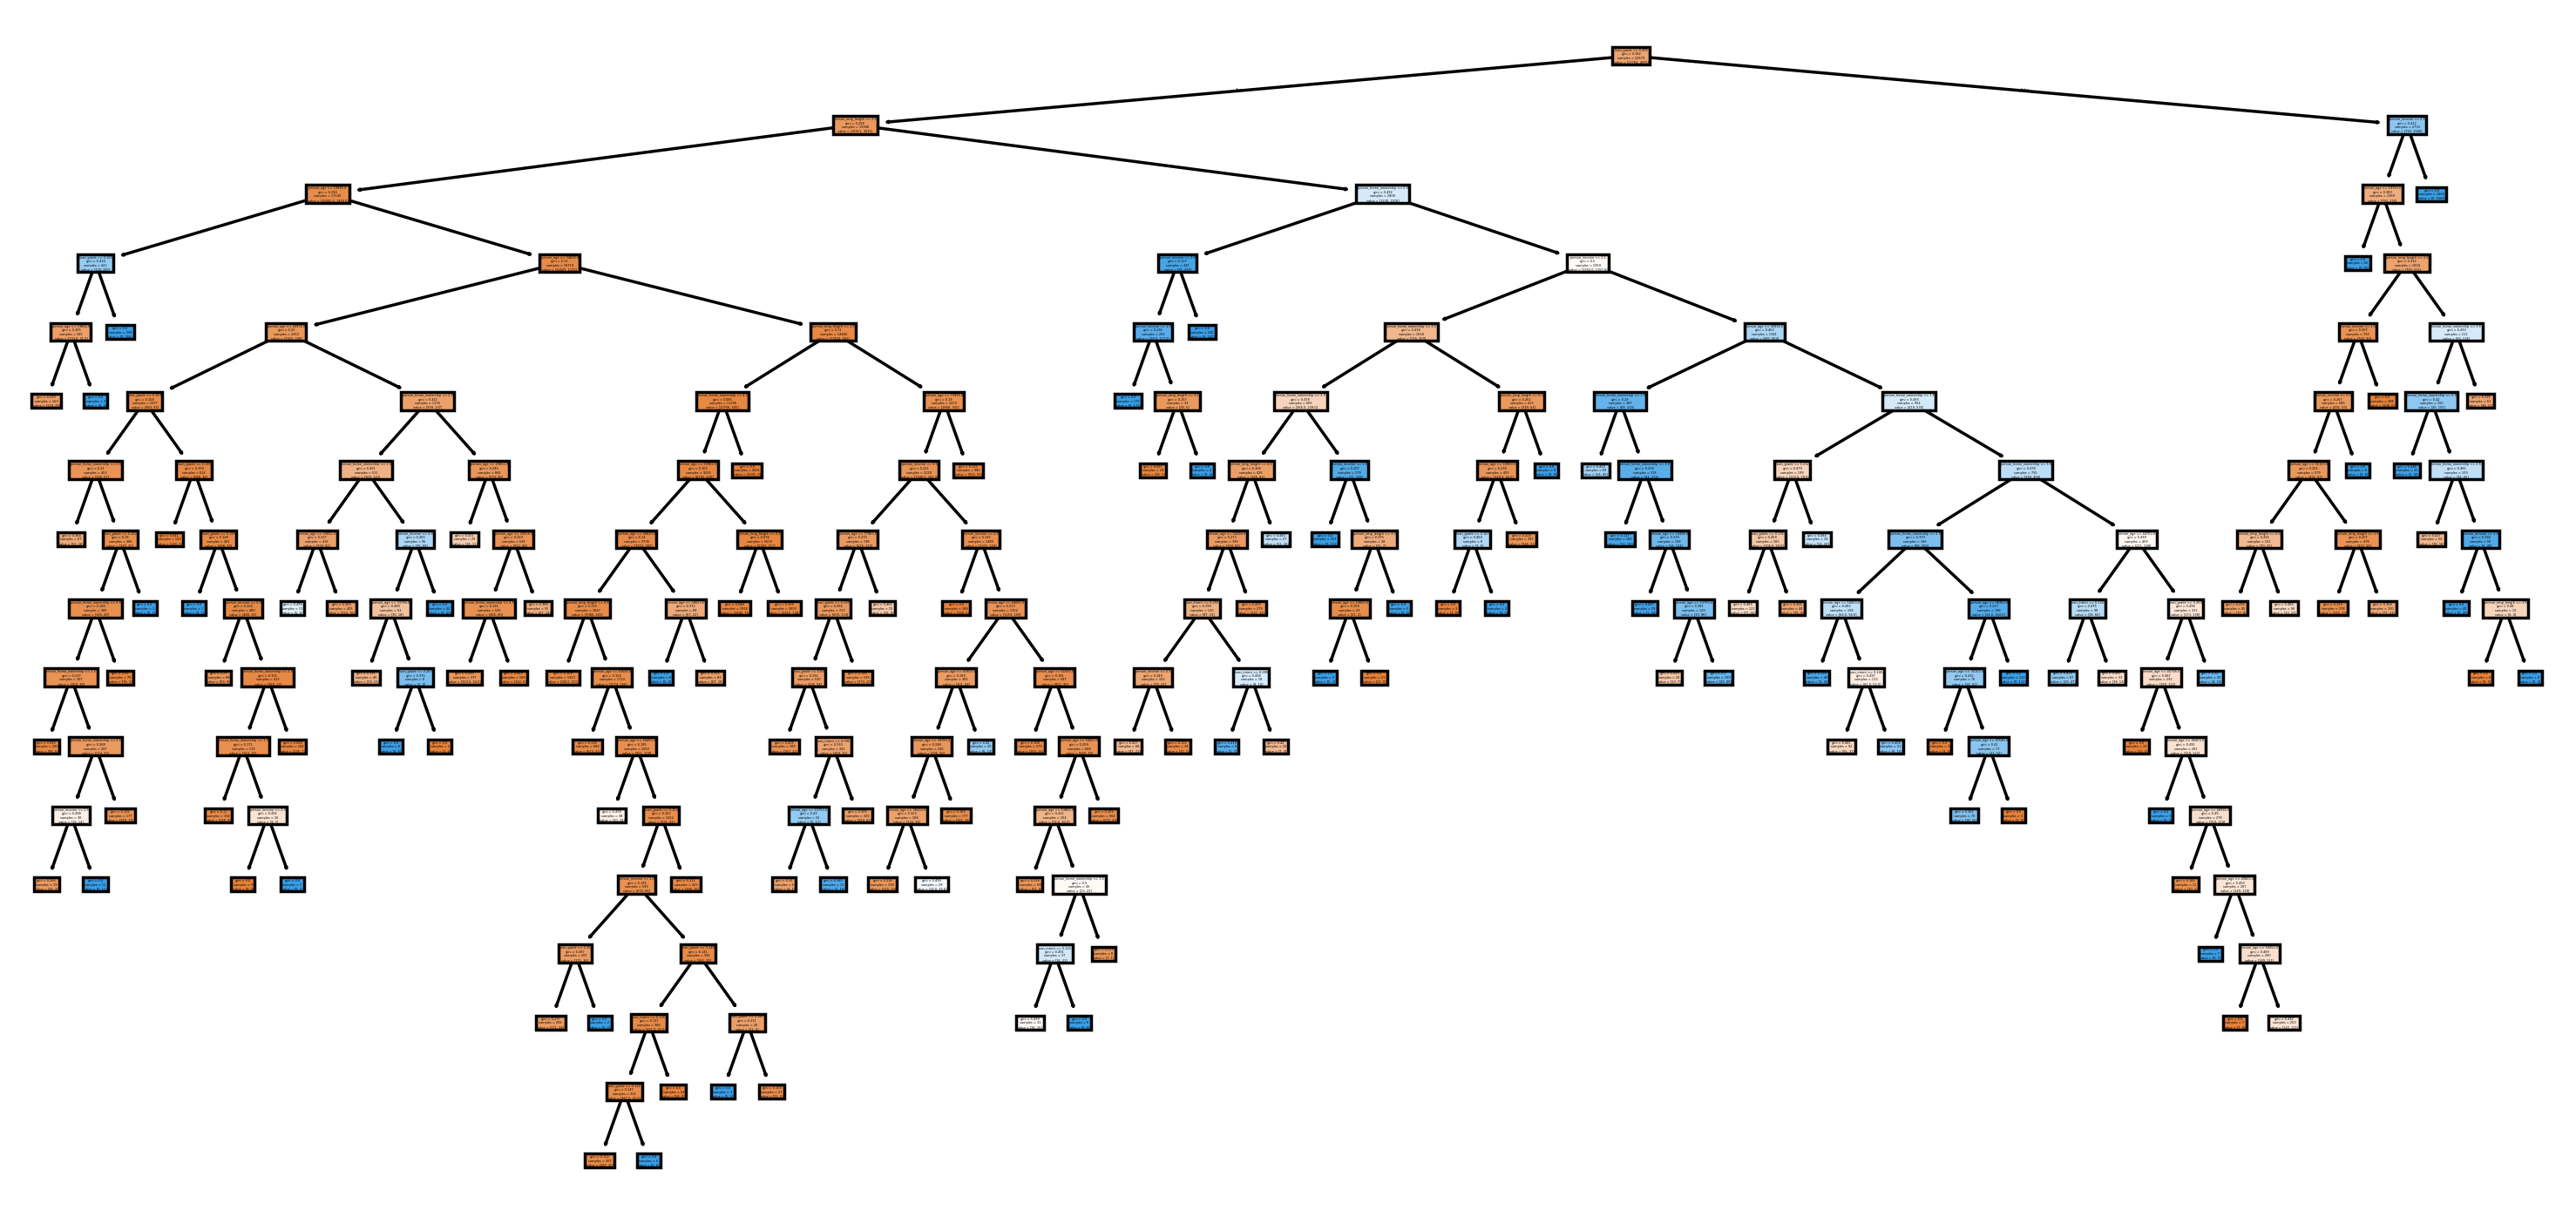

In [65]:
plt.figure(figsize=(15, 7), dpi=250)
plot_tree(tree_clf2, feature_names=my_data_set.columns, filled=True);

### Tune SVM Regularization Parameter (C)  

This section investigates how changing the regularization parameter `C` influences the performance of a Support Vector Machine (SVM) classifier with a Radial Basis Function (RBF) kernel.

- **Support Vector Machine (SVM)** is a supervised learning algorithm widely used for classification tasks. It finds the optimal hyperplane that separates classes in the feature space by maximizing the margin between data points of different classes.
  
- The **RBF kernel** allows the SVM to handle non-linear relationships by mapping the input features into a higher-dimensional space where classes can be separated linearly.

- The **regularization parameter `C`** controls the trade-off between achieving a low training error and maintaining a large margin:
  - A **small `C` value** makes the margin wider but allows more misclassifications, which can lead to underfitting.
  - A **large `C` value** tries to classify all training points correctly, possibly causing overfitting to noise in the data.

- This code trains SVM models with different values of `C` from 0.1 to 10.0.
- For each model, it calculates accuracy on both the training and test datasets.
- Finally, it plots these accuracies against the `C` values to visually identify the optimal regularization strength that balances bias and variance.

This process helps in selecting the best `C` value to improve the model’s generalization on unseen data.


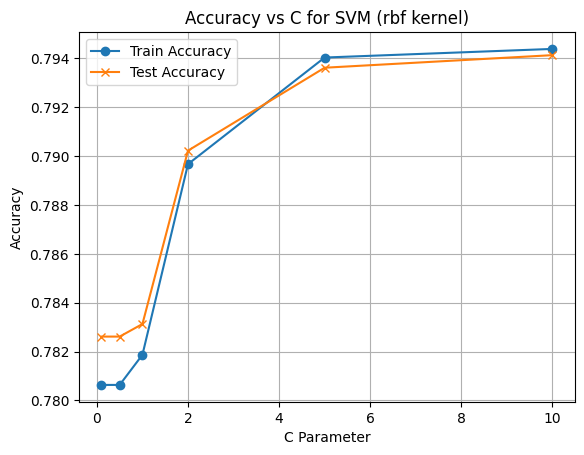

In [32]:
C_values = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
train_accuracies = []
test_accuracies = []
for C in C_values:
    svm = SVC(kernel='rbf', random_state=1, C=C)
    svm.fit(X_train, y_train)
    train_pred = svm.predict(X_train)
    test_pred = svm.predict(X_test)
    train_accuracies.append(accuracy_score(y_train, train_pred))
    test_accuracies.append(accuracy_score(y_test, test_pred))
plt.plot(C_values, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(C_values, test_accuracies, marker='x', label='Test Accuracy')
plt.xlabel('C Parameter')
plt.ylabel('Accuracy')
plt.title('Accuracy vs C for SVM (rbf kernel)')
plt.legend()
plt.grid(True)
plt.show()

### Tune SVM Kernel Parameter (Gamma)  

This section explores how the `gamma` parameter affects the performance of a Support Vector Machine (SVM) with an RBF kernel.

- The **gamma parameter** determines the influence range of a single training example:
  - A **small gamma** means a large influence radius, resulting in smoother decision boundaries and possibly underfitting.
  - A **large gamma** means a small influence radius, allowing the model to capture more complex patterns but risking overfitting.

- Here, the SVM is trained with a fixed regularization parameter `C=4.0` and varying `gamma` values ranging from 0.001 to 1.0.
- For each gamma, the model is evaluated on the test data, and accuracy scores are recorded.
- The accuracy vs. gamma plot helps identify the best gamma value to balance bias and variance for better generalization.

Tuning gamma is crucial because it controls the complexity of the decision boundary in the feature space created by the RBF kernel.


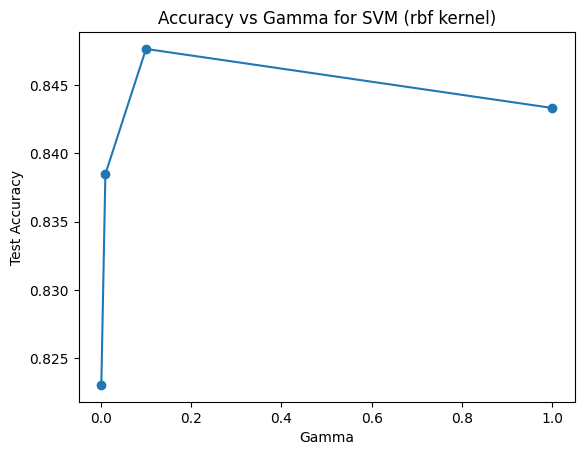

In [33]:
gamma_values = [0.001, 0.01, 0.1, 1.0]
accuracies = []
for gamma in gamma_values:
    svm = SVC(kernel='rbf', random_state=1, C=4.0, gamma=gamma)
    svm.fit(X_train, y_train)
    accuracies.append(svm.score(X_test, y_test))
plt.plot(gamma_values, accuracies, marker='o')
plt.xlabel('Gamma')
plt.ylabel('Test Accuracy')
plt.title('Accuracy vs Gamma for SVM (rbf kernel)')
plt.show()

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svm = SVC(kernel='rbf', random_state=1, C=4, gamma=0.1)
svm.fit(X_train, y_train)
train_accuracy = svm.score(X_train, y_train)
test_accuracy = svm.score(X_test, y_test)
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Train Accuracy: 0.9161
Test Accuracy: 0.8476


### Evaluate SVM Model with Confusion Matrix  

This section evaluates the performance of the SVM classifier by using a confusion matrix, which breaks down predictions into four categories:

- **True Positive (TP):** The model correctly predicts the positive class.  
- **True Negative (TN):** The model correctly predicts the negative class.  
- **False Positive (FP):** The model incorrectly predicts the positive class when it is actually negative (Type I error).  
- **False Negative (FN):** The model incorrectly predicts the negative class when it is actually positive (Type II error).  

The confusion matrix helps us understand not only the overall accuracy but also the types of errors the model makes. Accuracy is calculated as the proportion of correct predictions (TP + TN) out of all predictions. Visualizing the confusion matrix with a heatmap makes it easier to interpret these results and identify potential weaknesses in the model.


<Figure size 800x600 with 0 Axes>

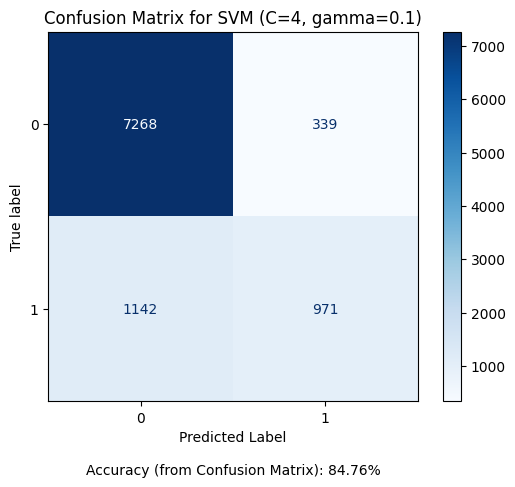

Correct Predictions (TP + TN): 8239
Total Predictions: 9720
Accuracy (from Confusion Matrix): 0.8476


In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.svm import SVC
svm = SVC(kernel='rbf', random_state=1, C=4, gamma=0.1)
svm.fit(X_train, y_train)
predictions_svm = svm.predict(X_test)
cm = confusion_matrix(y_test, predictions_svm)
correct_predictions = cm.diagonal().sum()
total_predictions = cm.sum()
accuracy_from_cm = correct_predictions / total_predictions
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for SVM (C=4, gamma=0.1)')
plt.xlabel(f'Predicted Label\n\nAccuracy (from Confusion Matrix): {accuracy_from_cm:.2%}')
plt.show()
print(f"Correct Predictions (TP + TN): {correct_predictions}")
print(f"Total Predictions: {total_predictions}")
print(f"Accuracy (from Confusion Matrix): {accuracy_from_cm:.4f}")

### Compare Accuracy Breakdown Between SVM and Decision Tree Models  

This section compares the classification accuracy of two models—SVM and Decision Tree—by visualizing the proportions of correct and incorrect predictions.  

- The confusion matrices for each model are manually defined to extract the number of correct (true positives + true negatives) and incorrect predictions.  
- Accuracy is calculated as the ratio of correct predictions to total predictions.  
- Pie charts display the percentage of correct versus incorrect predictions for both models side-by-side, making it easier to compare their overall effectiveness visually.  
- This comparison helps in selecting the better performing model for the task based on accuracy and error rates.


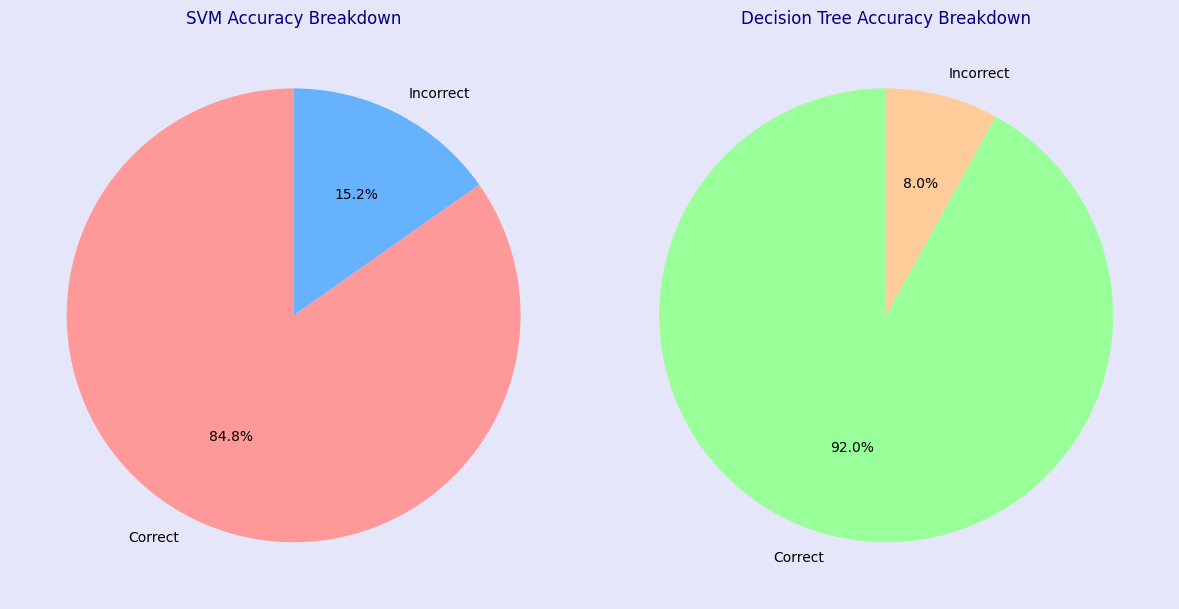

In [33]:
svm_cm = np.array([[7268, 339], [1142, 971]])  
tree_cm = np.array([[7501, 106], [673, 1440]])  
svm_correct = svm_cm.diagonal().sum() / svm_cm.sum()
tree_correct = tree_cm.diagonal().sum() / tree_cm.sum()
svm_incorrect = 1 - svm_correct
tree_incorrect = 1 - tree_correct
models = ['SVM', 'Decision Tree']
correct_data = [svm_correct, tree_correct]
incorrect_data = [svm_incorrect, tree_incorrect]
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'] 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.pie([svm_correct, svm_incorrect], labels=['Correct', 'Incorrect'], colors=[colors[0], colors[1]], autopct='%1.1f%%', startangle=90)
ax2.pie([tree_correct, tree_incorrect], labels=['Correct', 'Incorrect'], colors=[colors[2], colors[3]], autopct='%1.1f%%', startangle=90)
ax1.set_title('SVM Accuracy Breakdown', color='navy')
ax2.set_title('Decision Tree Accuracy Breakdown', color='navy')
plt.gcf().patch.set_facecolor('#E6E6FA')
plt.tight_layout()
plt.show()